In [2]:
# ======================================================================
# Importação das Bibliotecas Necessárias
# ======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import yfinance as yf

🚀 Iniciando Treinamento do Sistema de Preço Dinâmico
Preços disponíveis: [ 20.  25.  30.  35.  40.  45.  50.  55.  60.  65.  70.  75.  80.  85.
  90.  95. 100.]
Custo unitário: R$15.00
Inventário inicial: 100 unidades
------------------------------------------------------------
🧠 Treinando agente com aprendizado por reforço...
Dia 0: Preço R$20.00, Lucro R$285.00, Lucro Médio R$0.00, Exploração: 0.298
Dia 100: Preço R$100.00, Lucro R$1700.00, Lucro Médio R$675.45, Exploração: 0.181
Dia 200: Preço R$20.00, Lucro R$235.00, Lucro Médio R$1096.40, Exploração: 0.110
Dia 300: Preço R$90.00, Lucro R$2250.00, Lucro Médio R$1049.70, Exploração: 0.066
Dia 400: Preço R$100.00, Lucro R$1105.00, Lucro Médio R$1218.25, Exploração: 0.040
Dia 500: Preço R$90.00, Lucro R$1875.00, Lucro Médio R$1242.65, Exploração: 0.024
Dia 600: Preço R$20.00, Lucro R$280.00, Lucro Médio R$1182.45, Exploração: 0.015
Dia 700: Preço R$45.00, Lucro R$1140.00, Lucro Médio R$1149.10, Exploração: 0.009
Dia 800: Preço R$70.00

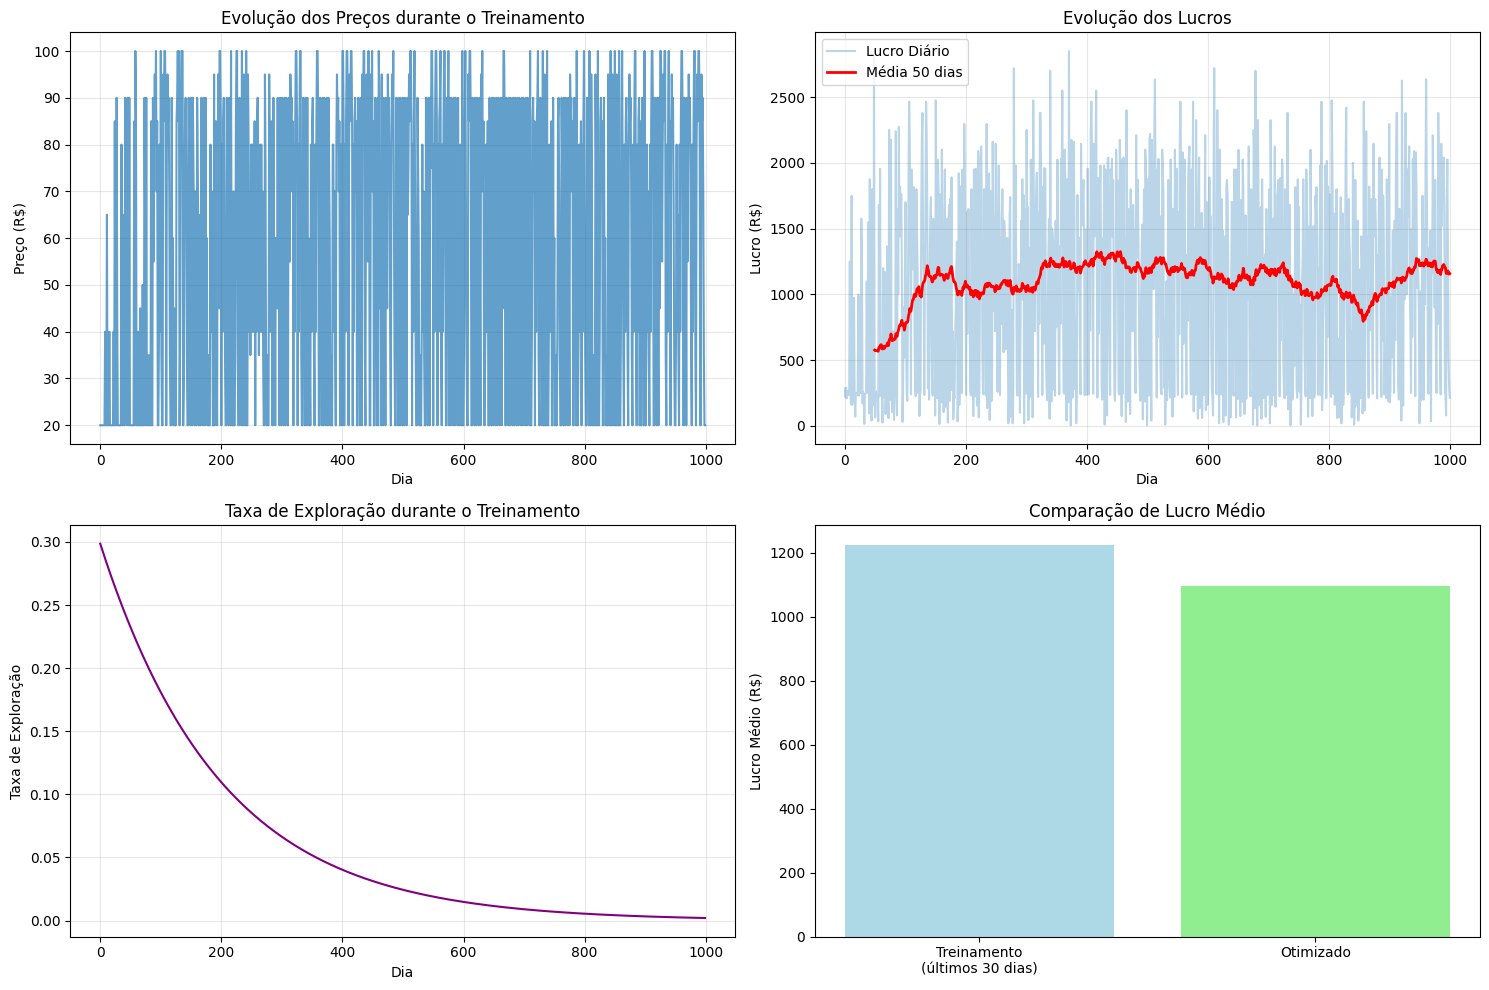


EXEMPLO DE USO EM TEMPO REAL
Inventário atual: 75
Dia da semana: 3 (Quinta-feira)
Preço recomendado: R$20.00
Demanda esperada: 38 unidades
Lucro esperado: R$190.00

🎉 Sistema de preço dinâmico pronto para implantação!


In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import defaultdict

# Configurações do ambiente
MAX_PRICE = 100.0
MIN_PRICE = 20.0
PRICE_STEP = 5.0
DEMAND_SENSITIVITY = 0.8  # Quão sensível é a demanda ao preço
COST_PER_UNIT = 15.0
INITIAL_INVENTORY = 100
MAX_DAYS = 365

# Parâmetros de aprendizado
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.95
EXPLORATION_RATE = 0.3
EXPLORATION_DECAY = 0.995

# Preços discretos disponíveis
def generate_price_levels(min_price, max_price, step):
    """Gera níveis de preço discretos"""
    return np.arange(min_price, max_price + step, step)

PRICE_LEVELS = generate_price_levels(MIN_PRICE, MAX_PRICE, PRICE_STEP)
N_PRICES = len(PRICE_LEVELS)

def initialize_environment():
    """Inicializa o ambiente de preço dinâmico"""
    return {
        'inventory': INITIAL_INVENTORY,
        'day': 0,
        'total_revenue': 0.0,
        'total_profit': 0.0,
        'sales_history': [],
        'price_history': [],
        'demand_history': []
    }

def calculate_demand(price, base_demand=50, sensitivity=DEMAND_SENSITIVITY):
    """Calcula a demanda baseada no preço"""
    # Função de demanda exponencial decrescente
    demand = base_demand * np.exp(-sensitivity * (price - MIN_PRICE) / (MAX_PRICE - MIN_PRICE))
    
    # Adiciona algum ruído aleatório
    noise = random.normalvariate(0, 5)
    demand = max(0, demand + noise)
    
    return int(round(demand))

def simulate_sales(price, inventory):
    """Simula as vendas baseadas no preço e inventário"""
    demand = calculate_demand(price)
    actual_sales = min(demand, inventory)
    revenue = actual_sales * price
    cost = actual_sales * COST_PER_UNIT
    profit = revenue - cost
    
    return {
        'demand': demand,
        'sales': actual_sales,
        'revenue': revenue,
        'profit': profit,
        'inventory_remaining': inventory - actual_sales
    }

def get_state(inventory, day):
    """Define o estado do sistema"""
    # Discretiza o inventário em níveis
    inventory_level = min(4, inventory // 25)  # 0-4 níveis
    # Discretiza o dia da semana (0-6)
    day_of_week = day % 7
    
    return (inventory_level, day_of_week)

def initialize_q_table():
    """Inicializa a tabela Q"""
    # Estado: (inventory_level, day_of_week) -> ações: preços
    return defaultdict(lambda: np.zeros(N_PRICES))

def choose_action(q_table, state, exploration_rate):
    """Escolhe uma ação usando política ε-greedy"""
    if random.random() < exploration_rate:
        # Exploração: escolhe preço aleatório
        return random.randint(0, N_PRICES - 1)
    else:
        # Exploração: escolhe melhor preço conhecido
        return np.argmax(q_table[state])

def update_q_table(q_table, state, action, reward, next_state, learning_rate, discount_factor):
    """Atualiza a tabela Q"""
    best_next_action = np.argmax(q_table[next_state])
    td_target = reward + discount_factor * q_table[next_state][best_next_action]
    td_error = td_target - q_table[state][action]
    q_table[state][action] += learning_rate * td_error
    
    return q_table

def train_pricing_agent(days=MAX_DAYS):
    """Treina o agente de preço dinâmico"""
    env = initialize_environment()
    q_table = initialize_q_table()
    exploration_rate = EXPLORATION_RATE
    
    history = {
        'profits': [],
        'revenues': [],
        'prices': [],
        'demands': [],
        'exploration_rates': []
    }
    
    for day in range(days):
        state = get_state(env['inventory'], env['day'])
        
        # Escolhe ação (preço)
        action = choose_action(q_table, state, exploration_rate)
        price = PRICE_LEVELS[action]
        
        # Executa ação e observa resultados
        sales_data = simulate_sales(price, env['inventory'])
        
        # Atualiza ambiente
        env['inventory'] = sales_data['inventory_remaining']
        env['total_revenue'] += sales_data['revenue']
        env['total_profit'] += sales_data['profit']
        env['day'] += 1
        
        # Recompensa: lucro normalizado
        reward = sales_data['profit'] / 100.0
        
        # Próximo estado
        next_state = get_state(env['inventory'], env['day'])
        
        # Atualiza Q-table
        q_table = update_q_table(q_table, state, action, reward, next_state, 
                               LEARNING_RATE, DISCOUNT_FACTOR)
        
        # Decai taxa de exploração
        exploration_rate *= EXPLORATION_DECAY
        
        # Armazena histórico
        history['profits'].append(sales_data['profit'])
        history['revenues'].append(sales_data['revenue'])
        history['prices'].append(price)
        history['demands'].append(sales_data['demand'])
        history['exploration_rates'].append(exploration_rate)
        
        # Reinicia inventário se necessário
        if env['inventory'] <= 0:
            env['inventory'] = INITIAL_INVENTORY
        
        if day % 100 == 0:
            avg_profit = np.mean(history['profits'][-100:]) if day > 0 else 0
            print(f"Dia {day}: Preço R${price:.2f}, Lucro R${sales_data['profit']:.2f}, "
                  f"Lucro Médio R${avg_profit:.2f}, Exploração: {exploration_rate:.3f}")
    
    return q_table, history, env

def optimize_price(q_table, inventory, day):
    """Otimiza o preço usando a política aprendida"""
    state = get_state(inventory, day)
    best_action = np.argmax(q_table[state])
    return PRICE_LEVELS[best_action]

def simulate_optimized_pricing(q_table, days=30):
    """Simula pricing otimizado após treinamento"""
    env = initialize_environment()
    results = []
    
    for day in range(days):
        price = optimize_price(q_table, env['inventory'], day)
        sales_data = simulate_sales(price, env['inventory'])
        
        env['inventory'] = sales_data['inventory_remaining']
        env['total_revenue'] += sales_data['revenue']
        env['total_profit'] += sales_data['profit']
        
        results.append({
            'day': day,
            'price': price,
            'demand': sales_data['demand'],
            'sales': sales_data['sales'],
            'revenue': sales_data['revenue'],
            'profit': sales_data['profit'],
            'inventory': env['inventory']
        })
        
        if env['inventory'] <= 0:
            env['inventory'] = INITIAL_INVENTORY
    
    return results

def analyze_performance(history, optimized_results):
    """Analisa o desempenho do sistema"""
    print("=" * 60)
    print("ANÁLISE DE DESEMPENHO - PREÇO DINÂMICO")
    print("=" * 60)
    
    # Estatísticas do treinamento
    train_profits = history['profits']
    train_avg_profit = np.mean(train_profits)
    train_std_profit = np.std(train_profits)
    
    # Estatísticas do período otimizado
    opt_profits = [r['profit'] for r in optimized_results]
    opt_avg_profit = np.mean(opt_profits)
    opt_std_profit = np.std(opt_profits)
    
    improvement = ((opt_avg_profit - train_avg_profit) / train_avg_profit) * 100
    
    print(f"\n📊 ESTATÍSTICAS DO TREINAMENTO ({len(train_profits)} dias):")
    print(f"   Lucro Médio: R${train_avg_profit:.2f} ± R${train_std_profit:.2f}")
    print(f"   Receita Total: R${sum(history['revenues']):.2f}")
    print(f"   Preço Médio: R${np.mean(history['prices']):.2f}")
    
    print(f"\n🎯 ESTATÍSTICAS OTIMIZADAS ({len(opt_profits)} dias):")
    print(f"   Lucro Médio: R${opt_avg_profit:.2f} ± R${opt_std_profit:.2f}")
    print(f"   Melhoria: {improvement:+.1f}%")
    print(f"   Receita Total: R${sum(r['revenue'] for r in optimized_results):.2f}")
    print(f"   Preço Médio: R${np.mean([r['price'] for r in optimized_results]):.2f}")
    
    return improvement

def plot_results(history, optimized_results):
    """Plota os resultados do treinamento"""
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Preços durante treinamento
    ax1.plot(history['prices'], alpha=0.7, label='Preço')
    ax1.set_title('Evolução dos Preços durante o Treinamento')
    ax1.set_xlabel('Dia')
    ax1.set_ylabel('Preço (R$)')
    ax1.grid(True, alpha=0.3)
    
    # Lucros
    window = 50
    smoothed_profits = np.convolve(history['profits'], np.ones(window)/window, mode='valid')
    ax2.plot(history['profits'], alpha=0.3, label='Lucro Diário')
    ax2.plot(range(window-1, len(history['profits'])), smoothed_profits, 
             label=f'Média {window} dias', linewidth=2, color='red')
    ax2.set_title('Evolução dos Lucros')
    ax2.set_xlabel('Dia')
    ax2.set_ylabel('Lucro (R$)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Taxa de exploração
    ax3.plot(history['exploration_rates'], color='purple')
    ax3.set_title('Taxa de Exploração durante o Treinamento')
    ax3.set_xlabel('Dia')
    ax3.set_ylabel('Taxa de Exploração')
    ax3.grid(True, alpha=0.3)
    
    # Comparação final
    train_avg = np.mean(history['profits'][-30:])
    opt_profits = [r['profit'] for r in optimized_results]
    opt_avg = np.mean(opt_profits)
    
    ax4.bar(['Treinamento\n(últimos 30 dias)', 'Otimizado'], [train_avg, opt_avg], 
            color=['lightblue', 'lightgreen'])
    ax4.set_title('Comparação de Lucro Médio')
    ax4.set_ylabel('Lucro Médio (R$)')
    
    plt.tight_layout()
    plt.show()

def demonstrate_pricing_strategy(q_table):
    """Demonstra a estratégia de pricing em diferentes cenários"""
    print("\n" + "=" * 60)
    print("ESTRATÉGIA DE PRICING EM DIFERENTES CENÁRIOS")
    print("=" * 60)
    
    scenarios = [
        ("Inventário Alto (Fim de Semana)", 100, 5),   # Sábado
        ("Inventário Médio (Meio de Semana)", 50, 2),  # Quarta
        ("Inventário Baixo (Início de Semana)", 10, 0) # Segunda
    ]
    
    for desc, inventory, day in scenarios:
        price = optimize_price(q_table, inventory, day)
        demand = calculate_demand(price)
        sales = min(demand, inventory)
        revenue = sales * price
        profit = revenue - (sales * COST_PER_UNIT)
        
        print(f"\n{desc}:")
        print(f"   Inventário: {inventory}, Dia: {day}")
        print(f"   Preço Otimizado: R${price:.2f}")
        print(f"   Demanda Esperada: {demand}")
        print(f"   Vendas Esperadas: {sales}")
        print(f"   Lucro Esperado: R${profit:.2f}")

# Execução principal
if __name__ == "__main__":
    print("🚀 Iniciando Treinamento do Sistema de Preço Dinâmico")
    print("=" * 60)
    print(f"Preços disponíveis: {PRICE_LEVELS}")
    print(f"Custo unitário: R${COST_PER_UNIT:.2f}")
    print(f"Inventário inicial: {INITIAL_INVENTORY} unidades")
    print("-" * 60)
    
    # Treina o agente
    print("🧠 Treinando agente com aprendizado por reforço...")
    q_table, history, final_env = train_pricing_agent(days=1000)
    
    print("\n✅ Treinamento concluído!")
    print(f"📈 Lucro total durante treinamento: R${final_env['total_profit']:.2f}")
    print(f"💰 Receita total: R${final_env['total_revenue']:.2f}")
    
    # Simula período otimizado
    print("\n🎯 Simulando período com pricing otimizado...")
    optimized_results = simulate_optimized_pricing(q_table, days=100)
    
    # Analisa desempenho
    improvement = analyze_performance(history, optimized_results)
    
    # Demonstra estratégia
    demonstrate_pricing_strategy(q_table)
    
    # Plota resultados
    print("\n📊 Gerando gráficos de análise...")
    plot_results(history, optimized_results)
    
    # Exemplo de uso em tempo real
    print("\n" + "=" * 60)
    print("EXEMPLO DE USO EM TEMPO REAL")
    print("=" * 60)
    
    current_inventory = 75
    current_day = 3  # Quinta-feira
    
    optimal_price = optimize_price(q_table, current_inventory, current_day)
    expected_demand = calculate_demand(optimal_price)
    
    print(f"Inventário atual: {current_inventory}")
    print(f"Dia da semana: {current_day} (Quinta-feira)")
    print(f"Preço recomendado: R${optimal_price:.2f}")
    print(f"Demanda esperada: {expected_demand} unidades")
    print(f"Lucro esperado: R${expected_demand * (optimal_price - COST_PER_UNIT):.2f}")
    
    print("\n🎉 Sistema de preço dinâmico pronto para implantação!")

In [20]:
# ======================================================================
# FIM DO PROGRAMA
# ======================================================================